In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re

In [23]:
df = pd.read_csv('../data/used_cars.csv')
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [24]:
def basic_info(df: pd.DataFrame):
    number_of_row = df.shape[0]
    number_of_column = df.shape[1]
    duplicates = df.duplicated().sum()
    mem_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f'Number of rows: {number_of_row}')
    print(f'Number of columns: {number_of_column}')
    print(f'Duplicates: {duplicates}')
    print(f'Memory usage: {mem_mb:.2f} MB')
basic_info(df)

Number of rows: 4009
Number of columns: 12
Duplicates: 0
Memory usage: 2.58 MB


In [25]:
_BOOL_MAP = {
    "yes": 1, "no": 0, "true": 1, "false": 0,
    "y": 1, "n": 0, "1": 1, "0": 0,
}
_SYMBOL_PATTERN = re.compile(
    r"""
    ^\s*                    # leading whitespace
    [₹$€£¥₩%+\-]?          # optional currency or sign prefix
    [\s]?                   # optional space after symbol
    |                       # OR
    \s*                     # trailing whitespace
    (mi\.?|km\.?|kg\.?|lbs?\.?|mph|kph|hp|cc|°[cf]?|%|[₹$€£¥₩])
    \s*$                    # end
    """,
    re.IGNORECASE | re.VERBOSE,
)
_DATE_CHAR_PATTERN = re.compile(r"[/\-:]|jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec", re.IGNORECASE)

In [26]:
def _strip_to_numeric(value: str) -> str:
    """Remove currency symbols, units, commas from a string value."""
    v = _SYMBOL_PATTERN.sub("", str(value))         # strip prefix/suffix symbols
    v = v.replace(",", "")                          # remove thousand separators
    return v.strip()

In [27]:
def _is_dirty_numeric(series: pd.Series, sample_size: int = 50) -> bool:
    """
    Returns True if the column looks like a number wearing a costume.
    Tests on a sample: strip symbols → try float cast → check success rate.
    """
    sample = series.dropna().head(sample_size)
    if len(sample) == 0:
        return False
    success = 0
    for val in sample:
        try:
            float(_strip_to_numeric(str(val)))
            success += 1
        except ValueError:
            pass
    return (success / len(sample)) >= 0.90   # 90% must parse cleanly

In [28]:
def _is_dirty_boolean(series: pd.Series) -> bool:
    """
    Returns True if all unique non-null values map to yes/no/true/false etc.
    """
    unique_vals = set(series.dropna().astype(str).str.lower().unique())
    return unique_vals.issubset(_BOOL_MAP.keys())

In [29]:
def _is_mostly_numeric(series: pd.Series, threshold: float = 0.85) -> bool:
    """
    Returns True if pd.to_numeric coerces successfully on >threshold fraction.
    Catches columns like ["35", "40", "N/A", "55"] — mostly numeric, few bad rows.
    """
    coerced = pd.to_numeric(series, errors="coerce")
    non_null_original = series.notna().sum()
    if non_null_original == 0:
        return False
    success_rate = coerced.notna().sum() / non_null_original
    return success_rate >= threshold

In [30]:
def _clean_numeric_column(series: pd.Series) -> pd.Series:
    """Strip symbols and cast to float. Unparseable → NaN."""
    def _convert(val):
        try:
            return float(_strip_to_numeric(str(val)))
        except ValueError:
            return np.nan

    return series.apply(_convert)

In [31]:
def _clean_boolean_column(series: pd.Series) -> pd.Series:
    """Map yes/no/true/false → 1/0. Unknowns → NaN."""
    return series.astype(str).str.lower().map(_BOOL_MAP)

In [32]:
def _is_datetime_like(series: pd.Series, sample_size: int = 50, threshold: float = 0.85) -> bool:
    """
    Returns True if the column looks like dates.
    Guards against pure numeric columns (e.g. "2021") being misread as dates
    by requiring date-separator characters or month names in the raw text.
    """
    sample = series.dropna().astype(str).head(sample_size)
    if sample.empty:
        return False

    # require at least one value to contain a date-like character/word
    has_date_chars = sample.str.contains(_DATE_CHAR_PATTERN, regex=True).mean()
    if has_date_chars < 0.5:
        return False

    parsed = pd.to_datetime(sample, errors="coerce", format="mixed")
    success_rate = parsed.notna().mean()
    return success_rate >= threshold


def _clean_datetime_column(series: pd.Series) -> pd.Series:
    """Parse to datetime. Unparseable → NaT."""
    return pd.to_datetime(series, errors="coerce", format="mixed")

In [33]:
def run_basic_cleaning(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """
    Detects and fixes dirty columns automatically.

    Pass in the raw loaded DataFrame. Returns:
        - cleaned_df  : DataFrame with corrected dtypes
        - cleaning_report : dict logging what was changed and why
    """
    df = df.copy()
    report = {
        "converted_to_numeric": [],
        "converted_to_boolean": [],
        "coerced_mostly_numeric": [],
        "converted_to_datetime": [],
        "unchanged": [],
    }

    object_cols = df.select_dtypes(include=["object", "string", "category"]).columns

    for col in object_cols:
        series = df[col]

        # ── Priority 0: Datetime check (must run before boolean/numeric) ──────────
        if _is_datetime_like(series):
            df[col] = _clean_datetime_column(series)
            report["converted_to_datetime"].append(col)

        # ── Priority 1: Boolean check first (yes/no cols are also "numeric-ish") ──
        elif _is_dirty_boolean(series):
            df[col] = _clean_boolean_column(series)
            report["converted_to_boolean"].append(col)

        # ── Priority 2: Dirty numeric (currency, units, commas) ───────────────────
        elif _is_dirty_numeric(series):
            df[col] = _clean_numeric_column(series)
            report["converted_to_numeric"].append(col)

        # ── Priority 3: Mostly numeric with a few bad rows ────────────────────────
        elif _is_mostly_numeric(series):
            df[col] = pd.to_numeric(series, errors="coerce")
            report["coerced_mostly_numeric"].append(col)

        # ── No pattern matched: leave as-is for EDA to handle ────────────────────
        else:
            report["unchanged"].append(col)

    return df, report

In [34]:
cleaned_df, report = run_basic_cleaning(df)
cleaned_df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,1.0,10300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,1.0,38005.0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,1.0,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0


In [35]:
print(report)

{'converted_to_numeric': ['milage', 'price'], 'converted_to_boolean': ['clean_title'], 'coerced_mostly_numeric': [], 'converted_to_datetime': [], 'unchanged': ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident']}


In [36]:
# test_df = pd.DataFrame({
#     "price": ["$10,300", "$38,005", "$54,598", "$15,500"],
#     "milage": ["51,000 mi.", "34,742 mi.", "22,372 mi.", "88,900 mi."],
#     "clean_title": ["Yes", "Yes", "No", "Yes"],
#     "sale_date": ["2024-01-15", "15/02/2024", "Jan 20, 2024", "2024-03-10"],
#     "model_year": [2013, 2021, 2022, 2015],   # already int — should stay unchanged
# })
# cleaned_df, report = run_basic_cleaning(test_df)
# print(cleaned_df.dtypes)
# print(report)

In [37]:
cleaned_df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [38]:
## Missing Value report
def missing_value(df: pd.DataFrame):
    column = []
    for col in df:
        if df[col].isnull().any():
            print(col)
            print(df[col].isnull().sum())
            print(f"Missing Using Mean {df[col].isnull().mean() * 100:.2f}%")
            print(f"Missing Value {(df[col].isnull().sum() / len(df))*100:.2f}%")
    return column
print(missing_value(cleaned_df))

fuel_type
170
Missing Using Mean 4.24%
Missing Value 4.24%
accident
113
Missing Using Mean 2.82%
Missing Value 2.82%
clean_title
596
Missing Using Mean 14.87%
Missing Value 14.87%
[]


In [39]:
def missing_value(df: pd.DataFrame) -> pd.DataFrame:
    report = []
    for col in df.columns:
        missing_val = df[col].isnull().sum()
        if missing_val > 0:
            missing_pct = (missing_val / len(df)) * 100
            report.append({
                "Column": col,
                "Missing Count": missing_val,
                "Missing Percentage": missing_pct
            })
    report_df = pd.DataFrame(report)
    if not report_df.empty:
        report_df = report_df.sort_values(by="Missing Percentage", ascending=False).reset_index(drop=True)
    return report_df
report = missing_value(cleaned_df)
print(report)

        Column  Missing Count  Missing Percentage
0  clean_title            596           14.866550
1    fuel_type            170            4.240459
2     accident            113            2.818658


In [40]:
cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   str    
 1   model         4009 non-null   str    
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   float64
 4   fuel_type     3839 non-null   str    
 5   engine        4009 non-null   str    
 6   transmission  4009 non-null   str    
 7   ext_col       4009 non-null   str    
 8   int_col       4009 non-null   str    
 9   accident      3896 non-null   str    
 10  clean_title   3413 non-null   float64
 11  price         4009 non-null   float64
dtypes: float64(3), int64(1), str(8)
memory usage: 376.0 KB


In [41]:
cleaned_df['price'].kurt()

np.float64(595.8928539362047)

In [59]:
def descriptive_statics(df: pd.DataFrame):
    numerical_col = df.select_dtypes(include=["number", "float", "int64"]).columns.tolist()
    categorical_col = df.select_dtypes(include=["object", "category"]).columns.tolist()
    stats_report = {"numerical": {}, "categorical": {}}
    highly_skewd = []
    # Statics extraction for the numerical columns
    for col in numerical_col:
        mean = df[col].mean()
        median = df[col].median()
        std = df[col].std()
        min = df[col].mean()
        max = df[col].max()
        skewness = df[col].skew()
        if(abs(skewness) > 1):
            highly_skewd.append(col)
        kurtosis = df[col].kurt()
        print(f"Column: {col}")
        print(f"mean: {mean:.4f}")      # The :.4f rounds the number to 4 decimal places for cleaner output
        print(f"median: {median:.4f}")
        print(f"std: {std:.4f}")
        print(f"min: {min:.4f}")
        print(f"max: {max:.4f}")
        print(f"skewness: {skewness:.4f}")
        print(f"kurtosis: {kurtosis:.4f}")
        print("-" * 20)
        stats_report["numerical"][col] = {
            "mean": mean,
            "median": median,
            "std": std,
            "min": min,
            "max": max,
            "skew": skewness,
            "kurtosis": kurtosis
        }
    # Statics extraction for the Categorial columns
    for col in categorical_col:
        counts = df[col].value_counts()
        top_value = counts.index[0]
        top_frequency = counts.iloc[0]
        print(f"Column: {col}")
        print(f"unique count: {len(counts)}")  # Or df[col].nunique()
        print(f"top value: {top_value}")
        print(f"top value frequency: {top_frequency}")
        print("-" * 20)
        stats_report["categorical"][col] = {
            "counts": counts,
            "top_value": top_value,
            "top_frequency": top_frequency,
        }
    return stats_report, highly_skewd

stats_report, highly_skewd = descriptive_statics(cleaned_df)
print(highly_skewd)

Column: model_year
mean: 2015.5156
median: 2017.0000
std: 6.1048
min: 2015.5156
max: 2024.0000
skewness: -1.0892
kurtosis: 1.1016
--------------------
Column: milage
mean: 64717.5510
median: 52775.0000
std: 52296.5995
min: 64717.5510
max: 405000.0000
skewness: 1.1600
kurtosis: 1.7497
--------------------
Column: clean_title
mean: 1.0000
median: 1.0000
std: 0.0000
min: 1.0000
max: 1.0000
skewness: 0.0000
kurtosis: 0.0000
--------------------
Column: price
mean: 44553.1903
median: 31000.0000
std: 78710.6356
min: 44553.1903
max: 2954083.0000
skewness: 19.5136
kurtosis: 595.8929
--------------------
Column: brand
unique count: 57
top value: Ford
top value frequency: 386
--------------------
Column: model
unique count: 1898
top value: M3 Base
top value frequency: 30
--------------------
Column: fuel_type
unique count: 7
top value: Gasoline
top value frequency: 3309
--------------------
Column: engine
unique count: 1146
top value: 2.0L I4 16V GDI DOHC Turbo
top value frequency: 52
----------

C:\Users\Shyam\AppData\Local\Temp\ipykernel_25392\752537469.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [43]:
(cleaned_df['price'][1]).item()

38005.0

In [54]:
def Outlier_detection(df: pd.DataFrame):
    numerical_col = df.select_dtypes(include=["number", "float", "int64"]).columns.tolist()
    outlier_report = {}
    for col in numerical_col:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3-q1
        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr
        count = 0
        for i in range(df.shape[0]):
            if (df[col][i]).item() < lower_limit:
                count += 1
            elif (df[col][i]).item() > upper_limit:
                count += 1
        print(f"{col} Outlier: {count}")
        outlier_report[col] = count
    return outlier_report
print(Outlier_detection(cleaned_df))

model_year Outlier: 67
milage Outlier: 69
clean_title Outlier: 0
price Outlier: 244
{'model_year': 67, 'milage': 69, 'clean_title': 0, 'price': 244}


In [45]:
cleaned_df.nunique()

brand             57
model           1898
model_year        34
milage          2818
fuel_type          7
engine          1146
transmission      62
ext_col          319
int_col          156
accident           2
clean_title        1
price           1569
dtype: int64

In [46]:
categorical_col = cleaned_df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_col

C:\Users\Shyam\AppData\Local\Temp\ipykernel_25392\1863873601.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = cleaned_df.select_dtypes(include=["object", "category"]).columns.tolist()


['brand',
 'model',
 'fuel_type',
 'engine',
 'transmission',
 'ext_col',
 'int_col',
 'accident']

In [47]:
def check_cardianility(df: pd.DataFrame) -> pd.DataFrame:
    report = {
        "Low Cardinality Prefer One Hot": set(),
        "High Cardinality Prefer Target / Feature Encoding": set(),
        "Flagged as Quasi-Constant! Consider dropping": set()
    }
    categorical_col = df.select_dtypes(include=["object", "category"]).columns.tolist()
    for col in categorical_col:
        # Edge case: If a column is completely empty, skip it to avoid errors
        if df[col].dropna().empty:
            continue
        dominant_value_percentage = df[col].value_counts(normalize=True).iloc[0]
        unique_count = df[col].nunique()
        if dominant_value_percentage > 0.95:
            report["Flagged as Quasi-Constant! Consider dropping"].add(col)
        if unique_count <= 10:
            report["Low Cardinality Prefer One Hot"].add(col)
        else:
            report["High Cardinality Prefer Target / Feature Encoding"].add(col)
    return report
print(check_cardianility(cleaned_df))

{'Low Cardinality Prefer One Hot': {'fuel_type', 'accident'}, 'High Cardinality Prefer Target / Feature Encoding': {'engine', 'brand', 'ext_col', 'transmission', 'int_col', 'model'}, 'Flagged as Quasi-Constant! Consider dropping': set()}


C:\Users\Shyam\AppData\Local\Temp\ipykernel_25392\897416054.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes(include=["object", "category"]).columns.tolist()


## Target Column Analysis

In [48]:
def load_user_data(file):
    extension = Path(file).suffix.lower()
    try:
        if extension == '.csv':
            df = pd.read_csv(file)
        elif extension in ['.xlsx', '.xls']:
            df = pd.read_excel(file)
        elif extension == '.json':
            df = pd.read_json(file)
        else:
            raise ValueError('File extension not supported')
        return df
    except Exception as e:
        print(f'An error occurred:{e}')
        return None
df = load_user_data("../data/classification_sample.xlsx")

In [49]:
def determine_type_of_PS(df, target_col=None):
    if target_col is None:
        print("It is Clustering")
        return "Clustering", None
    if target_col not in df.columns:
        raise ValueError(f'Column: {target_col} is not in the dataframe')
    y = df[target_col]
    uniques_values = y.nunique()
    total_rows = len(df)
    is_text = pd.api.types.is_object_dtype(y) or pd.api.types.is_string_dtype(y)
    is_category = (y.dtype.name == 'category')
    is_bool = pd.api.types.is_bool_dtype(y)
    if is_text or is_category or is_bool:
        return "Classification", target_col
    elif pd.api.types.is_numeric_dtype(y):
        if uniques_values < 15 and (total_rows > uniques_values*2):
            return "Clustering", target_col
        else:
            return "Regression", target_col
    else:
        return "Unknown", target_col
classification, taget_col = determine_type_of_PS(load_user_data(Path("../data/used_cars.csv")), target_col="price")
print(classification, taget_col)

Classification price


In [50]:
def target_column_analysis(df: pd.DataFrame, task_type: str, target_col: str):
    if task_type == "Clustering":
        return None
    if target_col not in df.columns:
        print("Column is not found in the dataframe")
        return None
    y = df[target_col]
    if task_type == "Classification":
        counts = y.value_counts()
        percentage = y.value_counts(normalize=True) * 100
        print(f"Target column: {target_col}")
        print(f"Number of classes: {y.nunique()}")
        print(counts)
        print(percentage.round(2))
        # Plot
        plt.figure(figsize=(8, 5))
        sns.countplot(x=y)
        plt.title(f"Class Distribution — {target_col}")
        plt.xlabel(target_col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        # Imbalance Ratio
        imbalance_ratio = counts.max() / counts.min()
        print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")
        # ── Flag minority classes < 5% share ────────────────────────────
        minority_classes = percentage[percentage < 5]
        is_imbalanced = not minority_classes.empty
        if is_imbalanced:
            print("⚠️ Class imbalance detected — classes under 5% share:")
            print(minority_classes.round(2))
        else:
            print("Class distribution looks balanced")

        return {
            "class_counts": counts.to_dict(),
            "class_percentages": percentage.to_dict(),
            "imbalance_ratio": imbalance_ratio,
            "is_imbalanced": is_imbalanced,
            "minority_classes": minority_classes.index.tolist()
        }
    elif task_type == "Regression":
        # ── Distribution plot ────────────────────────────────────────────
        plt.figure(figsize=(8, 5))
        sns.histplot(y, kde=True)
        plt.title(f"Target Distribution — {target_col}")
        plt.xlabel(target_col)
        plt.tight_layout()
        plt.show()
        # ── Skewness ─────────────────────────────────────────────────────
        skewness = y.skew()
        is_skewed = abs(skewness) > 1
        print(f"Target column: {target_col}")
        print(f"Skewness: {skewness:.3f}")
        if is_skewed:
            print("⚠️ Target is highly skewed — consider log transform")
        else:
            print("Target distribution looks roughly normal")
        return {
            "skewness": skewness,
            "is_skewed": is_skewed,
            "mean": y.mean(),
            "median": y.median(),
            "std": y.std()
        }
    else:
        print(f"Unknown task_type: {task_type} — skipping target analysis")
        return None

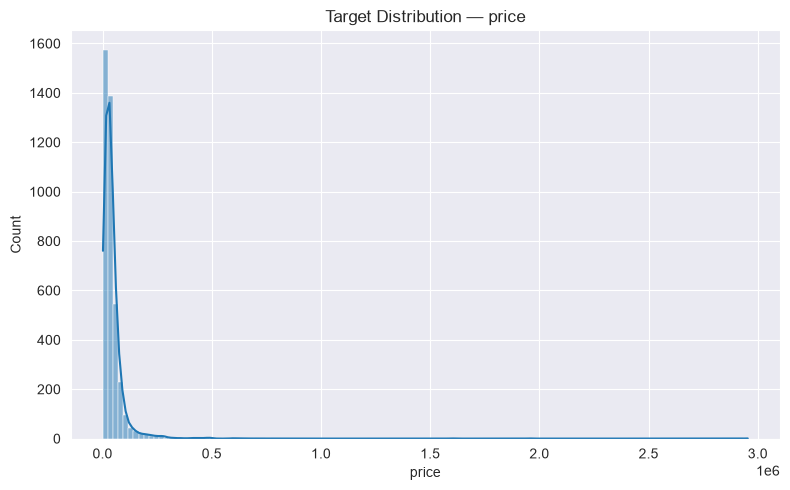

Target column: price
Skewness: 19.514
⚠️ Target is highly skewed — consider log transform
{'skewness': np.float64(19.51355120421606), 'is_skewed': np.True_, 'mean': np.float64(44553.190321776005), 'median': np.float64(31000.0), 'std': np.float64(78710.635554182)}


In [51]:
print(target_column_analysis(cleaned_df, "Regression", "price"))

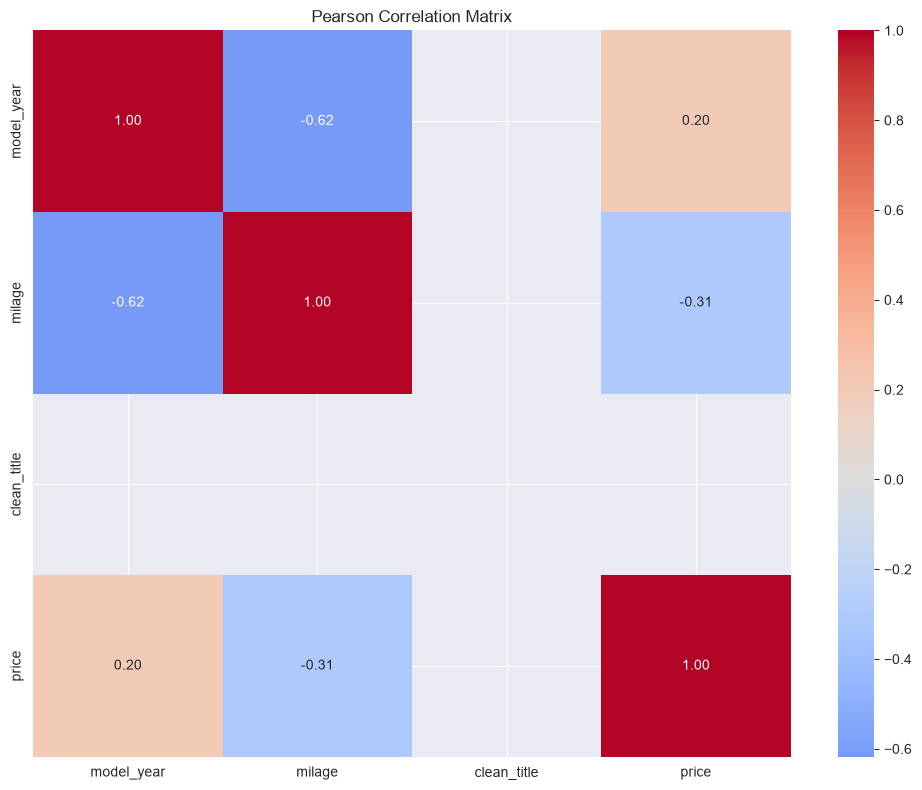


Feature correlation with target 'price' (ranked by |corr|):
milage        -0.306
model_year     0.199
clean_title      NaN
Name: price, dtype: float64
{'corr_matrix':              model_year    milage  clean_title     price
model_year     1.000000 -0.617720          NaN  0.199496
milage        -0.617720  1.000000          NaN -0.305528
clean_title         NaN       NaN          NaN       NaN
price          0.199496 -0.305528          NaN  1.000000, 'multicollinear_pairs': [], 'target_corr_ranked': milage        -0.305528
model_year     0.199496
clean_title         NaN
Name: price, dtype: float64}


In [53]:
def correlation_Analysis(df: pd.DataFrame, task_type: str = None, target_col: str = None, threshold: float = 0.85):
    numerical_column = numerical_col = df.select_dtypes(include=["number", "float", "int64"]).columns.tolist()
    if len(numerical_column) < 2:
        print("Not enough numerical columns to compute correlations")
        return None
    corr_matrix = df[numerical_col].corr(method="pearson")
    # ── Heatmap ──────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Pearson Correlation Matrix")
    plt.tight_layout()
    plt.show()
    # Multicollineraity
    multicollinear_pairs = []
    for i in range(len(numerical_column)):
        for j in range(i+1, len(numerical_column)):
            col_a, col_b = numerical_column[i], numerical_column[j]
            corr = corr_matrix.loc[col_a, col_b]
            if abs(corr) > threshold:
                multicollinear_pairs.append({
                    "col_a": col_a,
                    "col_b": col_b,
                    "corr": corr
                })
    if multicollinear_pairs:
        print(f"Total Multicollinear pairs: {len(multicollinear_pairs)}")
        for pair in multicollinear_pairs:
            print(f"Correlation between {pair["col_a"]} and {pair["col_b"]} is {pair["corr"]}")
    # ── Target correlation ranking (supervised tasks only) ──────────────────
    target_corr_ranked = None
    if task_type in ("Regression", "Classification") and target_col is not None:
        if target_col not in numerical_col:
            print(f"Target column '{target_col}' is not numeric — skipping target correlation ranking")
        else:
            target_corr = corr_matrix[target_col].drop(index=target_col)
            target_corr_ranked = target_corr.reindex(
                target_corr.abs().sort_values(ascending=False).index
            )
            print(f"\nFeature correlation with target '{target_col}' (ranked by |corr|):")
            print(target_corr_ranked.round(3))

    return {
        "corr_matrix": corr_matrix,
        "multicollinear_pairs": multicollinear_pairs,
        "target_corr_ranked": target_corr_ranked
    }
print(correlation_Analysis(cleaned_df, "Regression", "price"))